In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pymysql

In [4]:
conn = pymysql.connect(host = "localhost",
                           port = int(3306),
                           user = "root",
                           password ="sar1655",
                           db = "EDA")

In [5]:
cursor = conn.cursor()

In [6]:
cursor.execute('SELECT * FROM CUSTOMER')   
customer_data = pd.DataFrame(cursor.fetchall(),columns=[desc[0] for desc in cursor.description])  
print(customer_data)

   CUSTOMER_ID     NAME              CITY                       EMAIL  \
0        C1001    Steve             Tokyo             steve@gmail.com   
1        C1002     John            Sydney              john@gmail.com   
2        C1003    Peter          Kanagawa       peter.parker@mail.com   
3        C1004  Jackson             Tokyo           Jackson@gmail.com   
4        C1005     Jack  Lake Buena Vista              Jack@gmail.com   
5        C1006    Bruce            Gotham       bruce.wayne@gmail.com   
6        C1007    Clark        Metropolis        clark.kent@gmail.com   
7        C1008    Diana        Themyscira      diana.prince@gmail.com   
8        C1009     Tony          New York        tony.stark@gmail.com   
9        C1010  Natasha            Moscow  natasha.romanoff@gmail.com   
10       C1011    Wanda          Westview    wanda.maximoff@gmail.com   
11       C1012    Steve          Brooklyn      steve.rogers@gmail.com   
12       C1013     Thor            Asgard      thor

In [7]:
cursor.execute('SELECT * FROM PRODUCT')
product_data = pd.DataFrame(cursor.fetchall(), columns=[desc[0] for desc in cursor.description])
print(product_data)

   PRODUCT_ID     PRODUCT_NAME     CATEGORY        SUB_CATEGORY  \
0        P101            Chair    furniture              Chairs   
1        P102           Laptop  Electronics            computer   
2        P103       Smartphone  Electronics               phone   
3        P104          Blender    Appliance         Electronics   
4        P105        Laptop HP  Electronics           Computers   
5        P106            Table    furniture              Tables   
6        P107       Smartwatch  Electronics           Wearables   
7        P108     Refrigerator    Appliance             Kitchen   
8        P109       Headphones  Electronics         Accessories   
9        P110             Sofa    furniture         Living Room   
10       P111  Air Conditioner    Appliance             Cooling   
11       P112       Television  Electronics  Home Entertainment   
12       P113        Microwave    Appliance             Kitchen   
13       P114   Gaming Console  Electronics       Entertainmen

In [8]:
cursor.execute('SELECT * FROM ORDER_DETAILS')
order_data = pd.DataFrame(cursor.fetchall(), columns=[desc[0] for desc in cursor.description])
print(order_data)

    ORDER_ID CUSTOMER_ID PRODUCT_ID  QUANTITY  TOTAL_PRICE PAYMENT_MODE  \
0          1       C1004       P112       1.0      1000.00          COD   
1          2       C1005       P102       1.0     20000.00          COD   
2          3       C1005       P102       1.0     20000.00          COD   
3          4       C1006       P103       1.0     55000.00          COD   
4          5       C1006       P102       1.0     15000.00          COD   
5          6       C1007       P104       1.0     40000.00  Credit Card   
6          7       C1008       P105       2.0       900.00   Debit Card   
7          8       C1009       P106       1.0     55000.99  Net Banking   
8          9       C1010       P103       1.0     55000.00          COD   
9         10       C1011       P108       3.0     45000.00  Credit Card   
10        11       C1012       P110       5.0      7500.00          UPI   
11        12       C1013       P109       1.0     45000.00   Debit Card   
12        13       C1014 


# Exploratory Data Analysis (EDA) and Visualization: 

## ● CustomerAnalysis:
###   ○ Identify the total number of customers City wise.


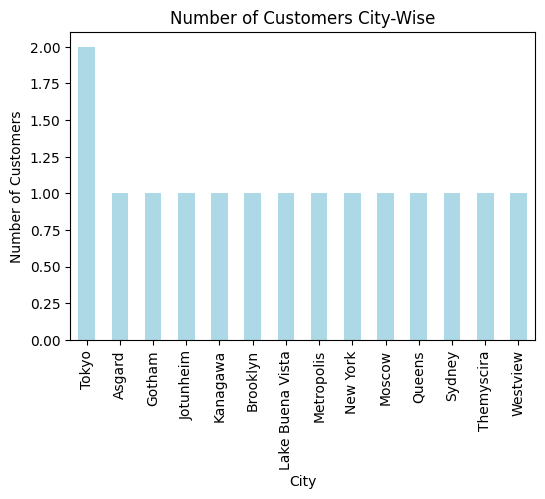

In [12]:
customer_data.groupby('CITY')['CUSTOMER_ID'].count().sort_values(ascending=False).plot(
                kind='bar',xlabel='City',ylabel='Number of Customers',
                  title='Number of Customers City-Wise',figsize=(6,4),color='lightblue')
plt.show()

###  ○ Identify the total number of customers City wise.


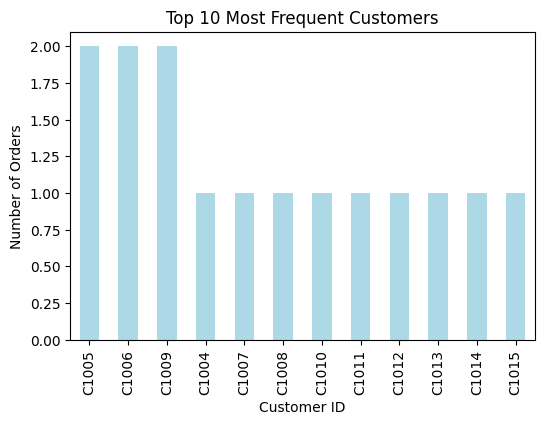

In [7]:
order_data.groupby('CUSTOMER_ID')['ORDER_ID'].count().sort_values(ascending=False).plot(
                kind='bar',xlabel='Customer ID',ylabel='Number of Orders',
                  title='Top 10 Most Frequent Customers',figsize=(6,4),color='lightblue')
plt.show() 

## ● Product Analysis:

### ○ Determine the total number of products available by category.

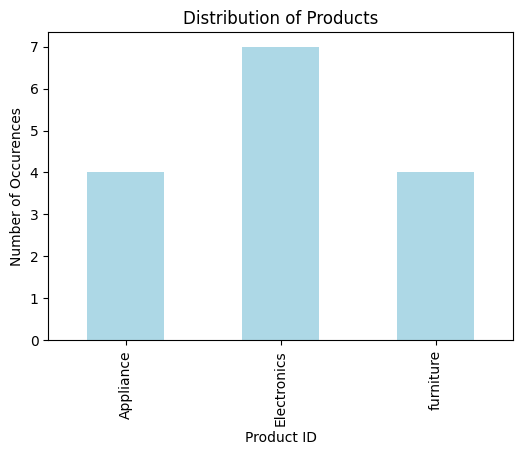

In [59]:
product_data.groupby('CATEGORY')['PRODUCT_ID'].count().plot(
                kind='bar',xlabel='Product ID',ylabel='Number of Occurences',
                  title='Distribution of Products',figsize=(6,4),color='lightblue')
plt.show() 

### ○ Analyzethe distribution of products across sub-categories.

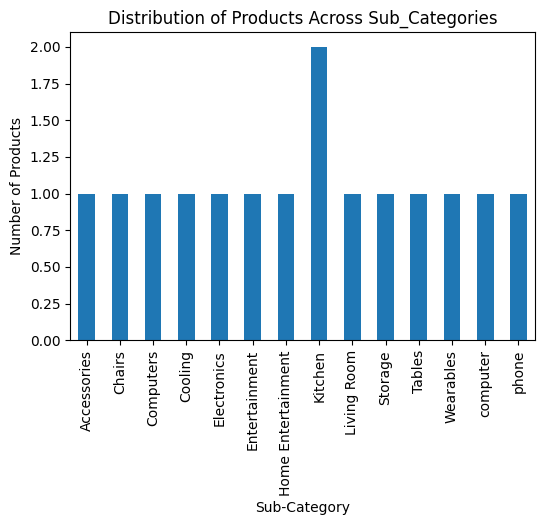

In [61]:
product_data.groupby('SUB_CATEGORY')['PRODUCT_ID'].count().plot(
                kind='bar',xlabel='Sub-Category',ylabel='Number of Products',
                  title='Distribution of Products Across Sub_Categories',figsize=(6,4))
plt.show() 

### ○ Identify products with low stock levels.

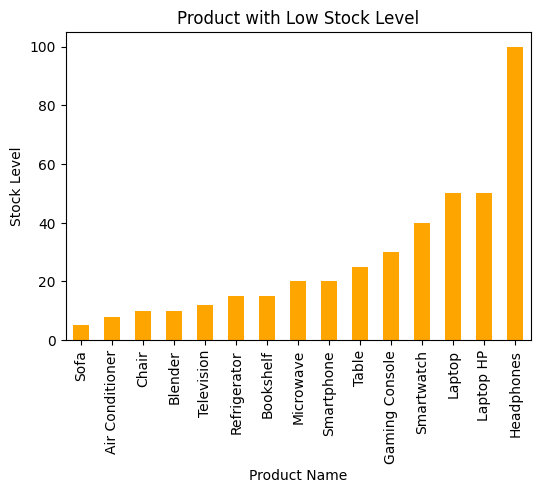

In [16]:
product_data.groupby('PRODUCT_NAME')['STOCK'].sum().sort_values().plot(
                kind='bar',xlabel='Product Name',ylabel='Stock Level',
                  title='Product with Low Stock Level',figsize=(6,4),color='orange')
plt.show()

### ○ Calculate the average, maximum, and minimum selling prices for products

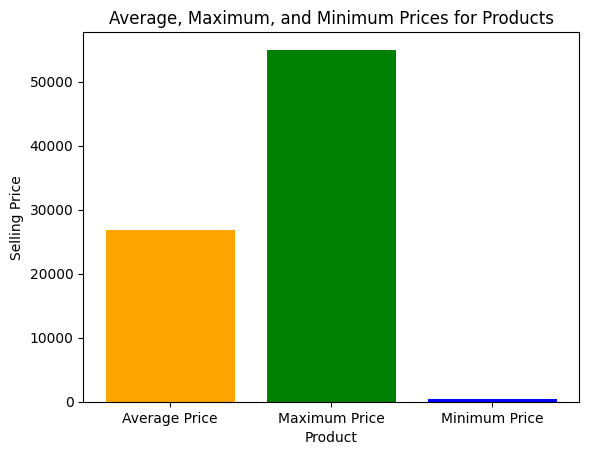

In [19]:
avg_price = product_data['SELLING_PRICE'].mean()
max_price = product_data['SELLING_PRICE'].max()
min_price = product_data['SELLING_PRICE'].min()
plt.bar(['Average Price', 'Maximum Price', 'Minimum Price'], [avg_price, max_price, min_price], color=['orange', 'green', 'blue'])
plt.title('Average, Maximum, and Minimum Prices for Products')
plt.ylabel('Selling Price')
plt.xlabel('Product')
plt.show()

## ● OrderAnalysis:

### ○ Calculate the top 10 orders product wise.

In [21]:
cursor.execute('SELECT P.PRODUCT_NAME, O.ORDER_ID FROM  ORDER_DETAILS O JOIN  PRODUCT P ON O.PRODUCT_ID = P.PRODUCT_ID;')   
c1 = pd.DataFrame(cursor.fetchall(),columns=[desc[0] for desc in cursor.description])

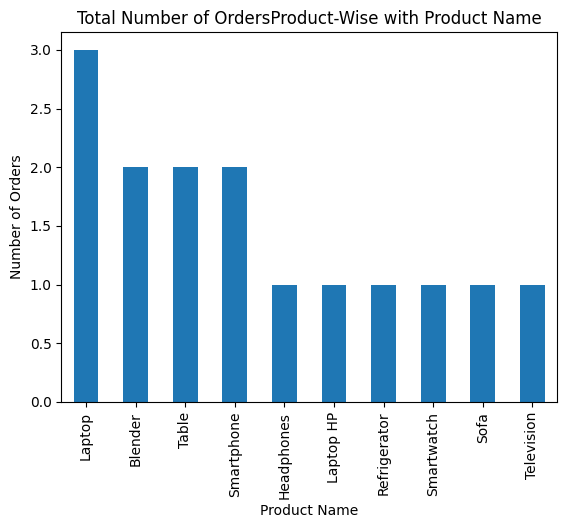

In [26]:
c1.groupby('PRODUCT_NAME')['ORDER_ID'].count().sort_values(ascending=False).plot(kind='bar',
                                                    xlabel='Product Name',
                                                    ylabel='Number of Orders',
                                                    title='Total Number of OrdersProduct-Wise with Product Name')
plt.show()

### ○ Analyzethe order status distribution (e.g., pending, delivered).

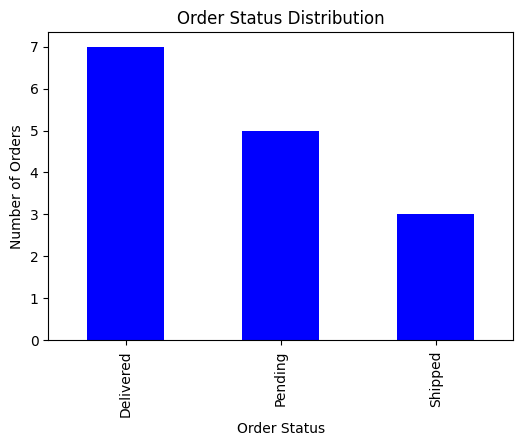

In [29]:
order_data.groupby('ORDER_STATUS')['ORDER_ID'].count().plot(
                kind='bar',xlabel='Order Status',ylabel='Number of Orders',
                title='Order Status Distribution',figsize=(6,4),color='blue')
plt.show()

### ○ Identify the most popular products based on order quantity.

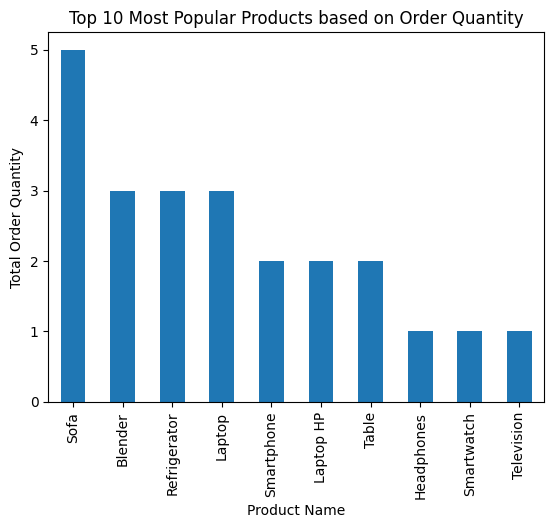

In [37]:
cursor.execute('SELECT P.PRODUCT_NAME, O.QUANTITY FROM  ORDER_DETAILS O JOIN  PRODUCT P ON O.PRODUCT_ID = P.PRODUCT_ID;')   
c2 = pd.DataFrame(cursor.fetchall(),columns=[desc[0] for desc in cursor.description]) 
c2.groupby('PRODUCT_NAME')['QUANTITY'].sum().sort_values(ascending=False).head(10).plot(kind='bar',
           ylabel='Total Order Quantity',
           xlabel='Product Name',
           title='Top 10 Most Popular Products based on Order Quantity')
plt.show()

## ● SalesAnalysis:

### ○ Calculate total revenue generated from orders product wise.

In [38]:
cursor.execute('SELECT P.PRODUCT_NAME, O.TOTAL_PRICE FROM  ORDER_DETAILS O JOIN  PRODUCT P ON O.PRODUCT_ID = P.PRODUCT_ID;')   
c3 = pd.DataFrame(cursor.fetchall(),columns=[desc[0] for desc in cursor.description]) 

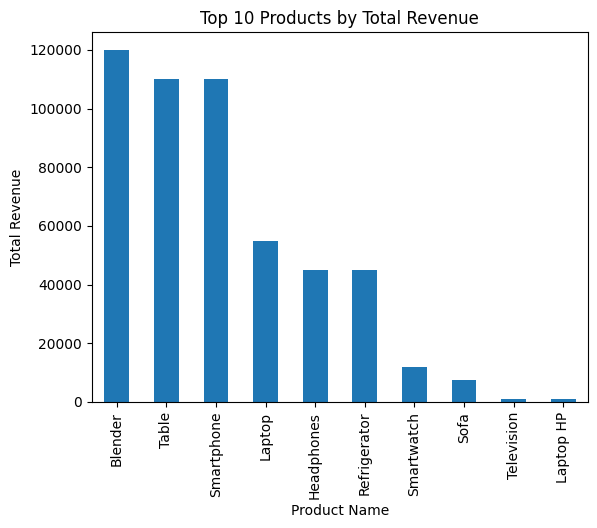

In [39]:
c3.groupby('PRODUCT_NAME')['TOTAL_PRICE'].sum().sort_values(ascending=False).head(10).plot(kind='bar',
           ylabel='Total Revenue',
           xlabel='Product Name',
           title='Top 10 Products by Total Revenue')
plt.show()

### ○ Calculate total revenue product category wise percentage.

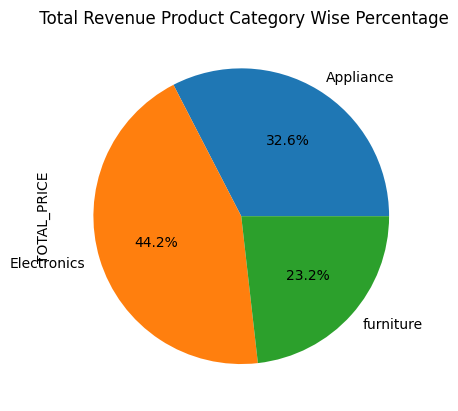

In [40]:
cursor.execute('SELECT P.CATEGORY, O.TOTAL_PRICE FROM  ORDER_DETAILS O JOIN  PRODUCT P ON O.PRODUCT_ID = P.PRODUCT_ID;')   
c4 = pd.DataFrame(cursor.fetchall(),columns=[desc[0] for desc in cursor.description]) 
c4.groupby('CATEGORY')['TOTAL_PRICE'].sum().plot(kind='pie', autopct="%1.1f%%",
           title=' Total Revenue Product Category Wise Percentage')
plt.show()

### ○ Calculate the total revenue generated from all orders

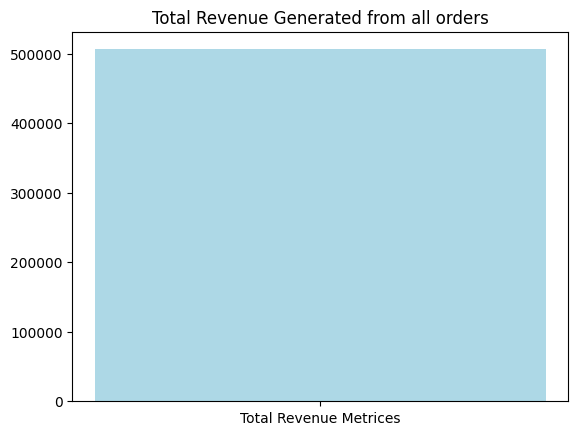

In [9]:
a=order_data['TOTAL_PRICE'].sum()
plt.bar(['Total Revenue Metrices'],[a],color='lightblue')
plt.title('Total Revenue Generated from all orders')
plt.show()

### ○ Identify the most profitable products based on the difference between original and selling prices.

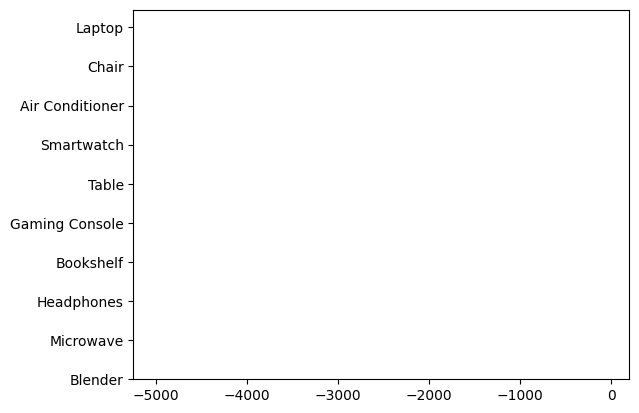

In [27]:
product_data['PROFIT'] = product_data['SELLING_PRICE']-product_data['ORIGINAL_PRICE']
ad=product_data[['PRODUCT_NAME', 'PROFIT']].sort_values(by='PROFIT', ascending=False).head(10)
plt.bar(ad['PROFIT'],ad['PRODUCT_NAME'],color='blue')
plt.xlabel=('Product_Name')
plt.ylabel=('profit(selling price - original price)')
plt.title=('Top 10 most profitable products')
plt.show()

## ● CustomerOrder Patterns:

### ○ Identify product names with the highest and lowest order quantities.

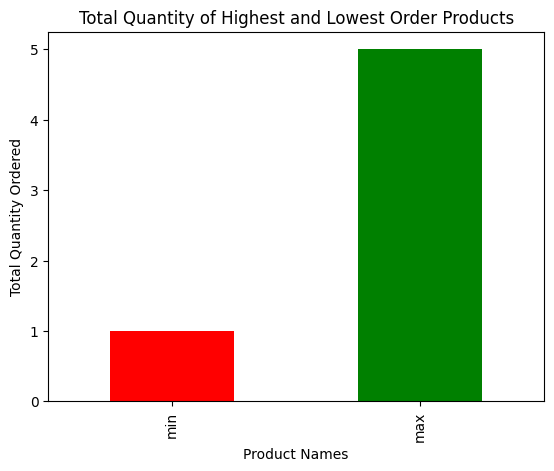

In [41]:
cursor.execute('SELECT P.PRODUCT_NAME, O.QUANTITY FROM  ORDER_DETAILS O JOIN  PRODUCT P ON O.PRODUCT_ID = P.PRODUCT_ID;')   
c5 = pd.DataFrame(cursor.fetchall(),columns=[desc[0] for desc in cursor.description]) 
c5.groupby('PRODUCT_NAME')['QUANTITY'].sum().agg(['min','max']).plot(kind='bar',
                                                                     color=['red','green'],
                                                                     xlabel='Product Names',
                                                                     ylabel='Total Quantity Ordered',
                                                                     title='Total Quantity of Highest and Lowest Order Products')
plt.show()

### ○ Identify customers with the highest and lowest order quantities by customer name. 

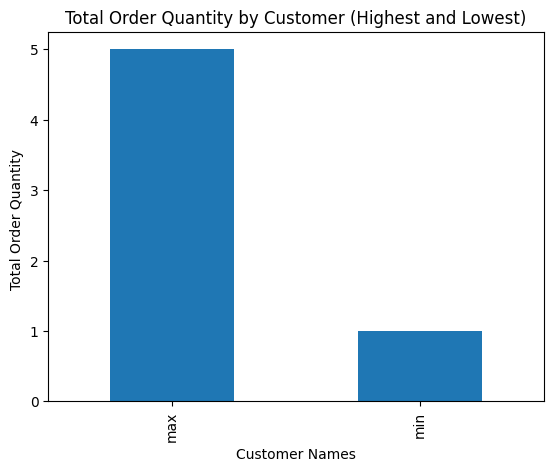

In [33]:
cursor.execute('SELECT C.NAME, O.QUANTITY FROM  ORDER_DETAILS O JOIN  CUSTOMER C ON O.CUSTOMER_ID = C.CUSTOMER_ID;')   
c6 = pd.DataFrame(cursor.fetchall(),columns=[desc[0] for desc in cursor.description]) 
c6.groupby('NAME')['QUANTITY'].sum().agg(['max','min']).plot(kind='bar',
                                                             xlabel='Customer Names',
                                                             ylabel='Total Order Quantity ',
                                                             title='Total Order Quantity by Customer (Highest and Lowest)')
plt.show()

### ○ Determine the most preferred payment modes.

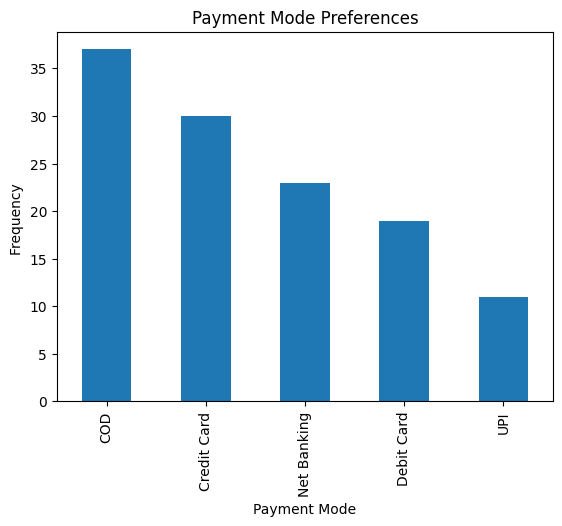

In [10]:
order_data.groupby('PAYMENT_MODE')['ORDER_ID'].sum().sort_values(ascending=False).plot(kind='bar', 
                                                                                       xlabel='Payment Mode',
                                                                                       ylabel='Frequency ',
                                                                                       title='Payment Mode Preferences')
plt.show()

##  ● Time-based Analysis:

### ○ Month wise total sales.

In [39]:
print(order_data.groupby('ORDER_DATE')['TOTAL_PRICE'].sum())

ORDER_DATE
2023-11-30    21000.00
2023-12-08    20000.00
2023-12-10    40000.00
2023-12-11    15900.00
2023-12-12    55000.99
2023-12-13    55000.00
2023-12-14    45000.00
2023-12-15    62500.00
2023-12-16    45000.00
2023-12-17    12000.00
2023-12-18    55000.99
2023-12-19    80000.00
Name: TOTAL_PRICE, dtype: float64


### ○ Identify peak order date.

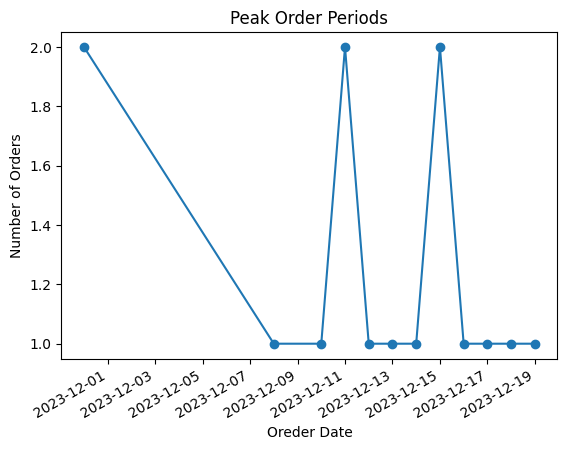

In [7]:
order_data.groupby('ORDER_DATE')['ORDER_ID'].count().plot(kind='line',marker='o',
                                                      xlabel='Oreder Date',
                                                      ylabel='Number of Orders',
                                                      title='Peak Order Periods')
plt.show()

## ● Geographical Analysis:

###  ○ Explore the distribution of customers across different cities.

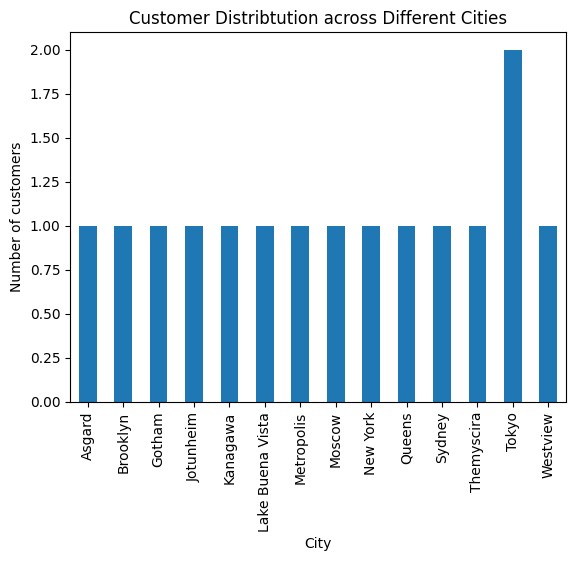

In [42]:
customer_data.groupby('CITY')['CUSTOMER_ID'].count().plot(kind='bar',
                                                          xlabel='City',
                                                          ylabel='Number of customers',
                                                          title='Customer Distribtution across Different Cities')
plt.show()

## ● Product Performance:

### ○ Identify the best-selling products.

In [8]:
cursor.execute('SELECT P.PRODUCT_NAME, O.QUANTITY FROM  ORDER_DETAILS O JOIN  PRODUCT P ON O.PRODUCT_ID = P.PRODUCT_ID;')   
c7 = pd.DataFrame(cursor.fetchall(),columns=[desc[0] for desc in cursor.description]) 

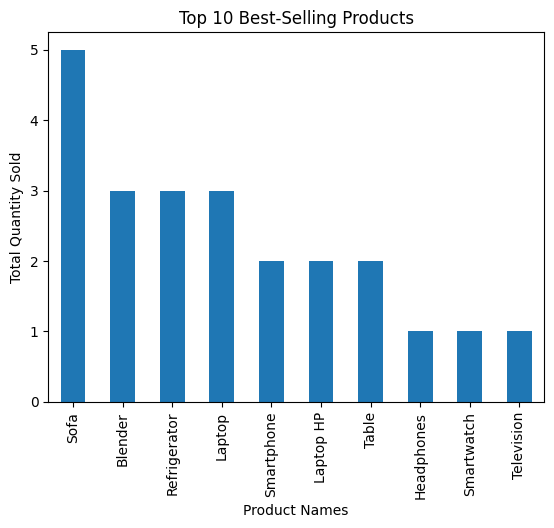

In [9]:
c7.groupby('PRODUCT_NAME')['QUANTITY'].sum().sort_values(ascending=False).head(10).plot(kind='bar',
                                                  xlabel='Product Names',
                                                  ylabel='Total Quantity Sold',
                                                  title='Top 10 Best-Selling Products')
plt.show()

### ○ Identify top 10 slow-moving products based on low sales.

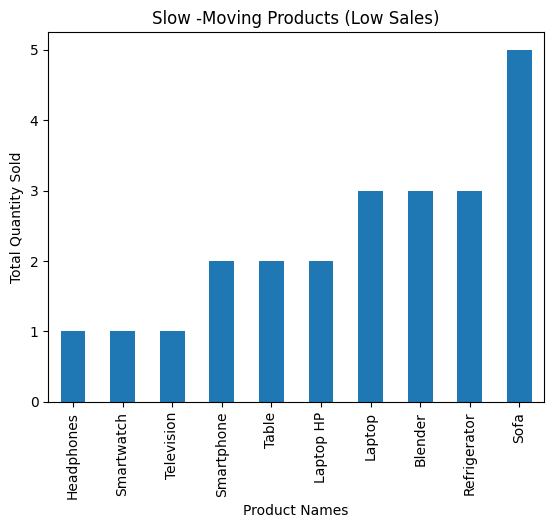

In [52]:
c7.groupby('PRODUCT_NAME')['QUANTITY'].sum().sort_values().tail(10).plot(kind='bar',
                                                  xlabel='Product Names',
                                                  ylabel='Total Quantity Sold',
                                                  title='Slow -Moving Products (Low Sales)')
plt.show()

## ● PaymentAnalysis:

### ○ Display successful and pending payments order counts.

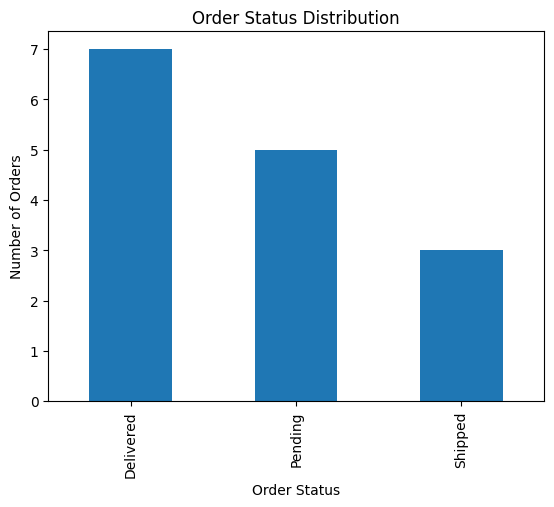

In [33]:
order_data.groupby('ORDER_STATUS')['ORDER_ID'].count().plot(kind='bar', 
                                                      xlabel='Order Status',
                                                      ylabel='Number of Orders',
                                                      title='Order Status Distribution')
plt.show()